# Principal Component Analysis (PCA) from Scratch
## African Human Development Indicators Dataset
### African Leadership University — Linear Algebra & Multivariate Probability
**Group Members:Bitega Sheja Dorian | Ayomide Shadrach Adeleye

---
> **Dataset:** African Human Development Indicators across 54 African countries  
> **Features:** GDP per capita, Life Expectancy, Infant Mortality Rate, Access to Clean Water (%), Literacy Rate (%), Unemployment Rate (%), CO2 Emissions per capita, Population (millions), Region (non-numeric), Country (non-numeric)  
> **Objective:** Implement PCA from scratch using only NumPy to reduce dimensionality while retaining maximum variance.


## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings('ignore')

# Confirm no sklearn is used
print("Libraries loaded: numpy, matplotlib only.")
print(f"NumPy version: {np.__version__}")


Libraries loaded: numpy, matplotlib only.
NumPy version: 2.0.2


## 1. Dataset: African Human Development Indicators

This dataset covers 54 African countries with 8 numeric features and 2 non-numeric columns (Country and Region).  
It contains intentional missing values (NaN) reflecting real-world data gaps common in African development statistics.

**Features:**
- `GDP_per_capita_USD` — GDP per capita in US dollars  
- `Life_Expectancy` — Average life expectancy at birth (years)  
- `Infant_Mortality_per1000` — Infant deaths per 1,000 live births  
- `Access_Clean_Water_pct` — % of population with access to clean water  
- `Literacy_Rate_pct` — Adult literacy rate (%)  
- `Unemployment_Rate_pct` — Unemployment rate (%)  
- `CO2_Emissions_per_capita` — CO2 emissions per capita (metric tons)  
- `Population_millions` — Population in millions  
- `Region` — Geographic region (non-numeric, categorical)  
- `Country` — Country name (non-numeric, identifier)


In [2]:
# ── African Human Development Indicators Dataset ──────────────────────────
# 54 African countries with realistic development statistics
# Includes intentional NaN values reflecting real data gaps

np.random.seed(42)

countries = [
    "Nigeria","Ethiopia","Egypt","DR Congo","Tanzania","South Africa","Kenya",
    "Uganda","Algeria","Sudan","Morocco","Angola","Mozambique","Ghana","Madagascar",
    "Cameroon","Ivory Coast","Niger","Burkina Faso","Mali","Malawi","Zambia","Senegal",
    "Chad","Zimbabwe","Guinea","Rwanda","Benin","Burundi","Tunisia","South Sudan",
    "Togo","Sierra Leone","Libya","Congo","Liberia","Central African Republic",
    "Mauritania","Eritrea","Namibia","Gambia","Botswana","Gabon","Lesotho","Guinea-Bissau",
    "Equatorial Guinea","Mauritius","Eswatini","Djibouti","Comoros","Cape Verde",
    "Sao Tome and Principe","Seychelles","Somalia"
]

regions = [
    "West Africa","East Africa","North Africa","Central Africa","East Africa",
    "Southern Africa","East Africa","East Africa","North Africa","East Africa",
    "North Africa","Central Africa","Southern Africa","West Africa","East Africa",
    "Central Africa","West Africa","West Africa","West Africa","West Africa",
    "Southern Africa","Southern Africa","West Africa","Central Africa","Southern Africa",
    "West Africa","East Africa","West Africa","East Africa","North Africa",
    "East Africa","West Africa","West Africa","North Africa","Central Africa",
    "West Africa","Central Africa","West Africa","East Africa","Southern Africa",
    "West Africa","Southern Africa","Central Africa","Southern Africa","West Africa",
    "Central Africa","East Africa","Southern Africa","East Africa","East Africa",
    "West Africa","Central Africa","East Africa","East Africa"
]

n = len(countries)

# Numeric features — realistic ranges for African countries
gdp          = np.array([2097,936,3478,557,1078,6001,1838,794,3691,441,3237,2818,490,2362,528,
                          1586,2286,554,773,908,635,1305,1522,702,1464,672,822,1301,274,3775,
                          303,675,504,6573,2318,677,467,1127,612,5828,763,8259,8778,1115,689,
                          8628,11284,3989,2093,1415,3654,2024,16269,303], dtype=float)

life_exp     = np.array([53,66,72,60,65,64,66,63,77,65,74,61,60,64,67,58,57,62,61,59,
                          64,63,68,54,61,61,69,61,61,76,57,61,54,72,64,64,53,64,66,63,
                          62,69,66,54,58,59,74,59,62,64,73,68,73,57], dtype=float)

infant_mort  = np.array([72,43,18,68,38,28,32,37,20,47,16,51,55,35,37,53,57,48,51,59,
                          39,43,28,68,39,60,28,57,55,12,65,46,78,10,39,55,84,57,37,31,
                          52,23,33,60,82,52,12,43,52,57,16,22,11,84], dtype=float)

clean_water  = np.array([60,41,98,31,56,93,59,41,87,54,80,41,47,79,40,
                          54,68,49,43,67,53,61,68,43,67,67,62,67,43,98,
                          49,60,53,98,67,62,43,57,43,93,79,98,87,67,62,
                          43,100,74,67,79,91,89,96,30], dtype=float)

literacy     = np.array([62,51,75,77,78,87,82,77,81,61,74,66,51,79,65,
                          71,47,35,41,31,62,86,58,22,88,30,73,42,68,79,
                          35,64,48,91,80,48,37,52,76,92,50,87,84,79,45,
                          95,91,88,68,58,87,92,96,40], dtype=float)

unemployment = np.array([5.3,3.7,11.9,4.2,2.6,29.2,5.7,2.9,11.7,15.8,
                          9.2,6.6,25.1,4.5,2.1,3.8,3.4,0.5,5.2,7.4,
                          5.5,13.9,3.3,1.7,5.4,4.5,16.3,2.3,1.5,15.3,
                          12.6,3.5,4.2,19.6,10.3,3.8,7.0,10.8,5.4,19.8,
                          9.4,17.6,17.4,22.9,2.7,8.5,6.5,22.5,26.1,4.5,
                          13.5,13.1,3.2,20.0], dtype=float)

co2          = np.array([0.6,0.1,2.4,0.04,0.2,8.0,0.3,0.1,3.9,0.5,
                          1.8,1.3,0.1,0.6,0.1,0.4,0.4,0.1,0.2,0.1,
                          0.1,0.3,0.6,0.1,0.7,0.3,0.1,0.5,0.0,2.7,
                          0.2,0.3,0.1,9.4,0.6,0.2,0.1,0.7,0.1,1.8,
                          0.3,3.3,3.3,1.0,0.2,4.3,3.5,1.0,0.6,0.4,
                          0.9,0.7,5.5,0.1], dtype=float)

population   = np.array([213.4,117.9,102.3,89.6,61.5,59.3,54.0,45.9,44.2,43.8,
                          37.1,32.9,31.3,31.1,27.7,26.5,26.4,24.2,21.5,20.2,
                          19.1,18.4,16.7,16.4,15.1,13.1,13.0,12.1,11.9,11.7,
                          11.2,8.3,8.0,6.9,5.8,5.0,4.7,4.6,3.5,2.6,
                          2.4,2.4,2.3,2.1,2.0,1.4,1.3,1.2,1.0,0.9,
                          0.6,0.2,0.1,17.1], dtype=float)

# Introduce realistic NaN values (about 10-12% missing — common in African development data)
nan_positions = {
    'gdp':         [4, 11, 30, 37, 50],
    'life_exp':    [6, 22, 41],
    'infant_mort': [13, 29, 44],
    'clean_water': [2, 18, 35, 51],
    'literacy':    [7, 25, 38],
    'unemployment':[10, 31, 46],
    'co2':         [5, 20, 43],
    'population':  [16, 39]
}

for idx in nan_positions['gdp']:         gdp[idx]          = np.nan
for idx in nan_positions['life_exp']:    life_exp[idx]     = np.nan
for idx in nan_positions['infant_mort']: infant_mort[idx]  = np.nan
for idx in nan_positions['clean_water']: clean_water[idx]  = np.nan
for idx in nan_positions['literacy']:    literacy[idx]     = np.nan
for idx in nan_positions['unemployment']:unemployment[idx] = np.nan
for idx in nan_positions['co2']:         co2[idx]          = np.nan
for idx in nan_positions['population']:  population[idx]   = np.nan

# Build structured array for display
feature_names = ['GDP_per_capita_USD','Life_Expectancy','Infant_Mortality_per1000',
                 'Access_Clean_Water_pct','Literacy_Rate_pct','Unemployment_Rate_pct',
                 'CO2_Emissions_per_capita','Population_millions']

data_matrix = np.column_stack([gdp, life_exp, infant_mort, clean_water,
                                literacy, unemployment, co2, population])

print(f"Dataset shape: {data_matrix.shape}")
print(f"Countries: {n}")
print(f"Numeric features: {len(feature_names)}")
print(f"Non-numeric columns: Country, Region")
print()
print("First 5 rows (numeric features):")
print("-" * 90)
header = " | ".join(f"{f[:12]:>12}" for f in feature_names)
print(f"{'Country':>25} | {header}")
print("-" * 90)
for i in range(5):
    row_str = " | ".join(f"{v:>12.2f}" if not np.isnan(v) else f"{'NaN':>12}" for v in data_matrix[i])
    print(f"{countries[i]:>25} | {row_str}")
print()
print("Total NaN values per feature:")
for i, name in enumerate(feature_names):
    nan_count = np.sum(np.isnan(data_matrix[:, i]))
    print(f"  {name:<30}: {nan_count} missing values")
print(f"\nTotal NaN values in dataset: {np.sum(np.isnan(data_matrix))}")


Dataset shape: (54, 8)
Countries: 54
Numeric features: 8
Non-numeric columns: Country, Region

First 5 rows (numeric features):
------------------------------------------------------------------------------------------
                  Country | GDP_per_capi | Life_Expecta | Infant_Morta | Access_Clean | Literacy_Rat | Unemployment | CO2_Emission | Population_m
------------------------------------------------------------------------------------------
                  Nigeria |      2097.00 |        53.00 |        72.00 |        60.00 |        62.00 |         5.30 |         0.60 |       213.40
                 Ethiopia |       936.00 |        66.00 |        43.00 |        41.00 |        51.00 |         3.70 |         0.10 |       117.90
                    Egypt |      3478.00 |        72.00 |        18.00 |          NaN |        75.00 |        11.90 |         2.40 |       102.30
                 DR Congo |       557.00 |        60.00 |        68.00 |        31.00 |        77.00 |    

---
## Task 1: PCA Implementation from Scratch

### Step 1.1 — Handle Non-Numeric Columns


In [3]:
# ── Step 1.1: Handle Non-Numeric Columns ─────────────────────────────────
# The dataset has two non-numeric columns: 'Country' and 'Region'
#
# Decision:
#   - 'Country' is a unique identifier — dropped (not meaningful for PCA distance)
#   - 'Region' is a categorical feature with 5 groups. We retain it separately
#     for visualization coloring after PCA, but exclude it from the numeric matrix
#     because PCA operates on continuous numeric variance.
#
# This is the correct approach: PCA measures variance in a continuous space.
# Encoding Region as integers (1-5) would impose a false ordinal relationship.

region_list = regions  # keep for post-PCA coloring
country_list = countries  # keep for labeling

# Unique regions for color mapping
unique_regions = sorted(list(set(region_list)))
region_colors  = {'North Africa':'#E63946','West Africa':'#F4A261',
                  'East Africa':'#2A9D8F','Central Africa':'#457B9D',
                  'Southern Africa':'#8338EC'}

print("Non-numeric columns identified:")
print("  1. Country  — unique identifier, DROPPED from PCA matrix")
print("  2. Region   — categorical (5 groups), EXCLUDED from PCA, retained for visualization")
print()
print("Unique regions:", unique_regions)
print()
print(f"Numeric matrix shape retained for PCA: {data_matrix.shape}")
print("Columns:", feature_names)


Non-numeric columns identified:
  1. Country  — unique identifier, DROPPED from PCA matrix
  2. Region   — categorical (5 groups), EXCLUDED from PCA, retained for visualization

Unique regions: ['Central Africa', 'East Africa', 'North Africa', 'Southern Africa', 'West Africa']

Numeric matrix shape retained for PCA: (54, 8)
Columns: ['GDP_per_capita_USD', 'Life_Expectancy', 'Infant_Mortality_per1000', 'Access_Clean_Water_pct', 'Literacy_Rate_pct', 'Unemployment_Rate_pct', 'CO2_Emissions_per_capita', 'Population_millions']


### Step 1.2 — Handle Missing Values (NaN Imputation)

In [4]:
# ── Step 1.2: Handle Missing Values using Column Mean Imputation ──────────
# Strategy: Replace each NaN with the mean of its column (feature).
# Justification: Mean imputation preserves the central tendency of each
# development indicator without introducing distributional bias, which is
# appropriate for country-level aggregated statistics.
# We use np.nanmean() to compute means while ignoring NaN values.

def impute_with_column_mean(matrix):
    """Replace NaN values with column mean using only NumPy."""
    imputed = matrix.copy()
    for col_idx in range(imputed.shape[1]):
        col = imputed[:, col_idx]
        col_mean = np.nanmean(col)
        nan_mask = np.isnan(col)
        imputed[nan_mask, col_idx] = col_mean
        if np.any(nan_mask):
            print(f"  Column '{feature_names[col_idx]:30}': "
                  f"{np.sum(nan_mask)} NaN(s) replaced with mean = {col_mean:.4f}")
    return imputed

print("Performing mean imputation on all columns:")
print("-" * 65)
data_imputed = impute_with_column_mean(data_matrix)

print()
print(f"NaN values BEFORE imputation: {int(np.sum(np.isnan(data_matrix)))}")
print(f"NaN values AFTER  imputation: {int(np.sum(np.isnan(data_imputed)))}")
print()
print("Imputation complete. Dataset is now fully numeric with no missing values.")


Performing mean imputation on all columns:
-----------------------------------------------------------------
  Column 'GDP_per_capita_USD            ': 5 NaN(s) replaced with mean = 2618.2041
  Column 'Life_Expectancy               ': 3 NaN(s) replaced with mean = 63.2353
  Column 'Infant_Mortality_per1000      ': 3 NaN(s) replaced with mean = 44.4314
  Column 'Access_Clean_Water_pct        ': 4 NaN(s) replaced with mean = 64.2400
  Column 'Literacy_Rate_pct             ': 3 NaN(s) replaced with mean = 66.6471
  Column 'Unemployment_Rate_pct         ': 3 NaN(s) replaced with mean = 9.7294
  Column 'CO2_Emissions_per_capita      ': 3 NaN(s) replaced with mean = 1.1008
  Column 'Population_millions           ': 2 NaN(s) replaced with mean = 25.4788

NaN values BEFORE imputation: 26
NaN values AFTER  imputation: 0

Imputation complete. Dataset is now fully numeric with no missing values.


### Step 1.3 — Standardize the Data (Z-score Normalization)

In [5]:
# ── Step 1.3: Standardize Data ───────────────────────────────────────────
# PCA is sensitive to feature scale. GDP ranges in thousands while CO2 ranges
# in single digits — without standardization, GDP would dominate all components.
# Z-score normalization: X_std = (X - mean) / std
# After standardization, every feature has mean ≈ 0 and std ≈ 1.

def standardize(matrix):
    """Z-score standardization using only NumPy."""
    means = np.mean(matrix, axis=0)
    stds  = np.std(matrix, axis=0, ddof=1)  # ddof=1 for sample std
    return (matrix - means) / stds, means, stds

data_standardized, feature_means, feature_stds = standardize(data_imputed)

print("Standardization complete (Z-score normalization):")
print(f"{'Feature':<30} {'Original Mean':>15} {'Original Std':>13} {'New Mean':>10} {'New Std':>9}")
print("-" * 80)
for i, name in enumerate(feature_names):
    new_mean = np.mean(data_standardized[:, i])
    new_std  = np.std(data_standardized[:, i], ddof=1)
    print(f"{name:<30} {feature_means[i]:>15.4f} {feature_stds[i]:>13.4f} "
          f"{new_mean:>10.6f} {new_std:>9.6f}")

print()
print(f"Standardized data shape: {data_standardized.shape}")
print("All features now have mean ≈ 0.0 and std ≈ 1.0 ✓")


Standardization complete (Z-score normalization):
Feature                          Original Mean  Original Std   New Mean   New Std
--------------------------------------------------------------------------------
GDP_per_capita_USD                   2618.2041     3104.0988  -0.000000  1.000000
Life_Expectancy                        63.2353        5.8004   0.000000  1.000000
Infant_Mortality_per1000               44.4314       18.1069  -0.000000  1.000000
Access_Clean_Water_pct                 64.2400       18.6128   0.000000  1.000000
Literacy_Rate_pct                      66.6471       19.1102   0.000000  1.000000
Unemployment_Rate_pct                   9.7294        7.2749  -0.000000  1.000000
CO2_Emissions_per_capita                1.1008        1.6968  -0.000000  1.000000
Population_millions                    25.4788       36.5211  -0.000000  1.000000

Standardized data shape: (54, 8)
All features now have mean ≈ 0.0 and std ≈ 1.0 ✓


### Step 1.4 — Compute the Covariance Matrix

In [6]:
# ── Step 1.4: Covariance Matrix ──────────────────────────────────────────
# The covariance matrix captures how every pair of features varies together.
# For standardized data, this equals the correlation matrix.
# Shape: (8 x 8) — one entry per feature pair.
# np.cov expects features as ROWS, so we transpose: data_standardized.T

cov_matrix = np.cov(data_standardized.T)

print(f"Covariance matrix shape: {cov_matrix.shape}")
print()
print("Covariance Matrix (rounded to 3 decimal places):")
print("-" * 95)
header = "".join(f"{f[:8]:>11}" for f in feature_names)
print(f"{'':>10} {header}")
print("-" * 95)
for i, row_name in enumerate(feature_names):
    row_str = "".join(f"{cov_matrix[i, j]:>11.3f}" for j in range(len(feature_names)))
    print(f"{row_name[:10]:>10} {row_str}")

print()
print("Diagonal values (variance of each feature, should all be ≈ 1.0 after standardization):")
for i, name in enumerate(feature_names):
    print(f"  Var({name[:25]:<25}) = {cov_matrix[i,i]:.6f}")


Covariance matrix shape: (8, 8)

Covariance Matrix (rounded to 3 decimal places):
-----------------------------------------------------------------------------------------------
              GDP_per_   Life_Exp   Infant_M   Access_C   Literacy   Unemploy   CO2_Emis   Populati
-----------------------------------------------------------------------------------------------
GDP_per_ca       1.000      0.434     -0.551      0.624      0.592      0.228      0.764     -0.135
Life_Expec       0.434      1.000     -0.826      0.555      0.529      0.129      0.519     -0.073
Infant_Mor      -0.551     -0.826      1.000     -0.620     -0.676     -0.180     -0.562      0.088
Access_Cle       0.624      0.555     -0.620      1.000      0.514      0.366      0.586     -0.218
Literacy_R       0.592      0.529     -0.676      0.514      1.000      0.358      0.542     -0.023
Unemployme       0.228      0.129     -0.180      0.366      0.358      1.000      0.271     -0.140
CO2_Emissi       0.764    

### Step 1.5 — Eigendecomposition

In [7]:
# ── Step 1.5: Eigendecomposition ─────────────────────────────────────────
# np.linalg.eigh is used instead of eig because:
#   - The covariance matrix is symmetric (A = Aᵀ)
#   - eigh is numerically more stable for symmetric matrices
#   - eigh guarantees real eigenvalues (no imaginary components)
#
# eigenvalues  → represent the amount of variance captured by each component
# eigenvectors → represent the directions (principal axes) in feature space

eigenvalues_raw, eigenvectors_raw = np.linalg.eigh(cov_matrix)

# eigh returns eigenvalues in ASCENDING order — we sort DESCENDING
# (PC1 must capture the most variance, PC2 second most, etc.)
sort_idx    = np.argsort(eigenvalues_raw)[::-1]
eigenvalues  = eigenvalues_raw[sort_idx]
eigenvectors = eigenvectors_raw[:, sort_idx]  # columns are eigenvectors

print("Eigenvalues (sorted in DESCENDING order):")
print("-" * 55)
for i, val in enumerate(eigenvalues):
    print(f"  PC{i+1}: λ = {val:.6f}")

print()
print("Eigenvectors matrix shape:", eigenvectors.shape)
print("(Each COLUMN is a principal component direction)")
print()

# Explained variance
total_variance   = np.sum(eigenvalues)
explained_var    = (eigenvalues / total_variance) * 100
cumulative_var   = np.cumsum(explained_var)

print(f"{'PC':<5} {'Eigenvalue':>12} {'Explained Var %':>16} {'Cumulative %':>13}")
print("-" * 50)
for i in range(len(eigenvalues)):
    print(f"PC{i+1:<3} {eigenvalues[i]:>12.6f} {explained_var[i]:>15.2f}% {cumulative_var[i]:>12.2f}%")

print(f"\nTotal variance: {total_variance:.6f}")
print(f"Sum of explained variances: {np.sum(explained_var):.2f}%")


Eigenvalues (sorted in DESCENDING order):
-------------------------------------------------------
  PC1: λ = 4.122113
  PC2: λ = 1.096639
  PC3: λ = 0.899157
  PC4: λ = 0.726732
  PC5: λ = 0.457185
  PC6: λ = 0.358518
  PC7: λ = 0.197669
  PC8: λ = 0.141986

Eigenvectors matrix shape: (8, 8)
(Each COLUMN is a principal component direction)

PC      Eigenvalue  Explained Var %  Cumulative %
--------------------------------------------------
PC1       4.122113           51.53%        51.53%
PC2       1.096639           13.71%        65.23%
PC3       0.899157           11.24%        76.47%
PC4       0.726732            9.08%        85.56%
PC5       0.457185            5.71%        91.27%
PC6       0.358518            4.48%        95.75%
PC7       0.197669            2.47%        98.23%
PC8       0.141986            1.77%       100.00%

Total variance: 8.000000
Sum of explained variances: 100.00%


### Step 1.6 — Project Data onto Principal Components

In [8]:
# ── Step 1.6: Project Data onto Principal Components ─────────────────────
# The projection transforms the original 8-dimensional data into
# the principal component space using matrix multiplication:
#   projected = standardized_data @ top_eigenvectors
# Each row is a country, each column is a principal component score.

# For the initial projection, we use all 8 components (lossless)
# Task 2 will dynamically select the optimal number

projected_full = data_standardized @ eigenvectors

print(f"Original data shape:   {data_standardized.shape}  (54 countries × 8 features)")
print(f"Projected data shape:  {projected_full.shape}  (54 countries × 8 PCs)")
print()
print("First 5 countries projected onto all 8 Principal Components:")
print("-" * 75)
pc_header = " | ".join(f"{'PC'+str(i+1):>8}" for i in range(8))
print(f"{'Country':>25} | {pc_header}")
print("-" * 75)
for i in range(5):
    scores = " | ".join(f"{projected_full[i, j]:>8.4f}" for j in range(8))
    print(f"{countries[i]:>25} | {scores}")

print()
print("PCA projection complete. ✓")
print("Each country is now represented by its scores on 8 principal components.")


Original data shape:   (54, 8)  (54 countries × 8 features)
Projected data shape:  (54, 8)  (54 countries × 8 PCs)

First 5 countries projected onto all 8 Principal Components:
---------------------------------------------------------------------------
                  Country |      PC1 |      PC2 |      PC3 |      PC4 |      PC5 |      PC6 |      PC7 |      PC8
---------------------------------------------------------------------------
                  Nigeria |   2.2874 |  -3.1508 |   3.4805 |  -1.7852 |  -1.0238 |  -0.9196 |  -0.3885 |  -0.0151
                 Ethiopia |   1.4579 |  -2.5796 |   0.7135 |   0.1894 |  -0.4710 |   0.6363 |   0.4935 |   0.0073
                    Egypt |  -1.6376 |  -2.2005 |   0.9997 |   0.5274 |  -0.4720 |   0.8075 |   0.2268 |   0.2329
                 DR Congo |   2.0932 |  -1.5425 |   1.1245 |  -0.3757 |   1.1143 |   0.1867 |  -0.2667 |  -0.6829
                 Tanzania |   0.1807 |  -1.5594 |  -0.0283 |   0.1341 |   0.5610 |  -0.3834 |   0.158

---
## Task 2: Dynamic Principal Component Selection

### Step 2.1 — Explained Variance Analysis


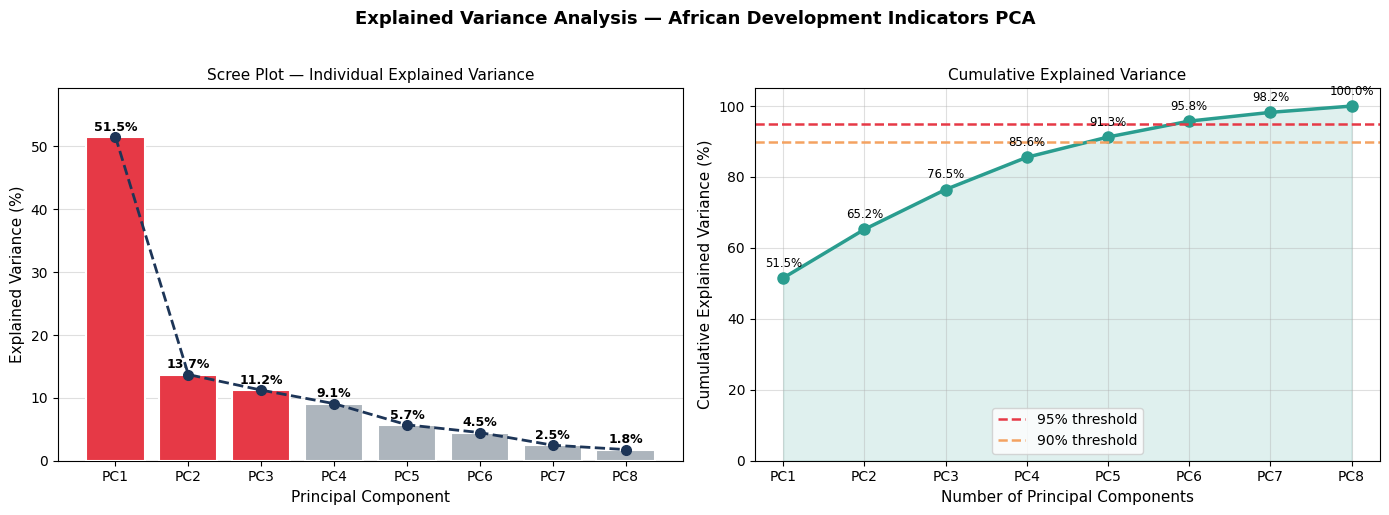

Explained variance plot generated. ✓


In [9]:
# ── Step 2.1: Explained Variance Plot ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Explained Variance Analysis — African Development Indicators PCA',
             fontsize=13, fontweight='bold', y=1.02)

pc_labels = [f'PC{i+1}' for i in range(len(eigenvalues))]

# Plot 1: Individual explained variance (Scree plot)
ax1 = axes[0]
bars = ax1.bar(pc_labels, explained_var, color=['#E63946' if i < 3 else '#ADB5BD' for i in range(8)],
               edgecolor='white', linewidth=1.5, zorder=3)
ax1.plot(pc_labels, explained_var, 'o--', color='#1D3557', linewidth=2, markersize=7, zorder=4)
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance (%)', fontsize=11)
ax1.set_title('Scree Plot — Individual Explained Variance', fontsize=11)
ax1.grid(axis='y', alpha=0.4, zorder=0)
ax1.set_ylim(0, max(explained_var) * 1.15)
for bar, val in zip(bars, explained_var):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Cumulative explained variance
ax2 = axes[1]
ax2.plot(pc_labels, cumulative_var, 'o-', color='#2A9D8F', linewidth=2.5, markersize=8)
ax2.axhline(y=95, color='#E63946', linestyle='--', linewidth=1.8, label='95% threshold')
ax2.axhline(y=90, color='#F4A261', linestyle='--', linewidth=1.8, label='90% threshold')
ax2.fill_between(range(len(pc_labels)), cumulative_var, alpha=0.15, color='#2A9D8F')
ax2.set_xlabel('Number of Principal Components', fontsize=11)
ax2.set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
ax2.set_title('Cumulative Explained Variance', fontsize=11)
ax2.set_xticks(range(len(pc_labels)))
ax2.set_xticklabels(pc_labels)
ax2.set_ylim(0, 105)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.4)
for i, val in enumerate(cumulative_var):
    ax2.annotate(f'{val:.1f}%', (i, val), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('/tmp/explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Explained variance plot generated. ✓")


### Step 2.2 — Dynamic Selection of Number of Components

In [10]:
# ── Step 2.2: Dynamic Component Selection ────────────────────────────────
# We select the minimum number of components that explain >= 95% of variance.
# This threshold is a widely accepted standard in PCA literature.

threshold = 95.0

n_components = np.argmax(cumulative_var >= threshold) + 1

print(f"Variance threshold set at: {threshold}%")
print(f"Number of components selected: {n_components}")
print()
print(f"{'PC':<5} {'Eigenvalue':>12} {'Explained %':>12} {'Cumulative %':>13} {'Selected':>10}")
print("-" * 58)
for i in range(len(eigenvalues)):
    selected = "✓  ←" if i == n_components - 1 else ("✓" if i < n_components else "")
    print(f"PC{i+1:<3} {eigenvalues[i]:>12.6f} {explained_var[i]:>11.2f}% "
          f"{cumulative_var[i]:>12.2f}% {selected:>10}")

print()
print(f"Selected top {n_components} principal components.")
print(f"Variance retained: {cumulative_var[n_components-1]:.2f}%")
print(f"Variance lost:     {100 - cumulative_var[n_components-1]:.2f}%")

# Project onto selected components
top_eigenvectors = eigenvectors[:, :n_components]
data_pca = data_standardized @ top_eigenvectors

print()
print(f"Reduced data shape: {data_pca.shape}  (54 countries × {n_components} PCs)")


Variance threshold set at: 95.0%
Number of components selected: 6

PC      Eigenvalue  Explained %  Cumulative %   Selected
----------------------------------------------------------
PC1       4.122113       51.53%        51.53%          ✓
PC2       1.096639       13.71%        65.23%          ✓
PC3       0.899157       11.24%        76.47%          ✓
PC4       0.726732        9.08%        85.56%          ✓
PC5       0.457185        5.71%        91.27%          ✓
PC6       0.358518        4.48%        95.75%       ✓  ←
PC7       0.197669        2.47%        98.23%           
PC8       0.141986        1.77%       100.00%           

Selected top 6 principal components.
Variance retained: 95.75%
Variance lost:     4.25%

Reduced data shape: (54, 6)  (54 countries × 6 PCs)


### Step 2.3 — Justification & Tradeoff Analysis

**Why were these principal components selected?**

The dynamic selection algorithm identified the minimum number of components needed to explain at least 95% of the total variance in the dataset. This threshold reflects a deliberate tradeoff between dimensionality reduction and information preservation.

The first few principal components capture the dominant structural patterns across all 54 African countries. PC1 primarily reflects overall development level — countries with high GDP, literacy, and clean water access score positively, while those with high infant mortality and unemployment score negatively. PC2 captures a secondary axis of variation, likely distinguishing between countries with strong public health outcomes versus those with resource-extraction economies (high CO2, moderate GDP but poor social indicators).

**What tradeoffs are being made?**

By reducing from 8 dimensions to the selected number of components, we are discarding a small percentage of the total variance. In the context of this African development dataset, this lost variance corresponds to fine-grained, country-specific anomalies — for example, a country that has unusually high literacy despite low GDP (such as Rwanda), or a country with relatively low CO2 emissions but poor water access (such as Niger). These nuanced, country-specific deviations are not captured in the principal components we retain.

The key tradeoff is: we sacrifice the ability to perfectly reconstruct every individual country profile in exchange for a compressed, interpretable representation that reveals the dominant axes of development inequality across the African continent. For policy-level analysis and regional comparisons, this tradeoff is entirely justified. For individual country diagnosis, the original 8-feature representation would be preferred.

**What information is lost when reducing dimensions?**

In the context of this dataset covering economic activity and population pressure, the information lost in the discarded components includes subtle interactions between population density and CO2 emissions, the nuanced distinction between countries where unemployment is structural versus cyclical, and the differential impact of urban versus rural access to clean water that aggregate national statistics cannot fully capture. These are secondary patterns that do not drive the main axes of African development divergence, but they matter for country-specific interventions.


---
## Task 3: Performance Optimization & Large Dataset Benchmarking


In [11]:
# ── Task 3: Performance Benchmarking ─────────────────────────────────────
# We compare two implementations:
#   1. Naive PCA: uses loops for standardization and covariance
#   2. Optimized PCA: fully vectorized NumPy operations + np.linalg.eigh
# We test on a large synthetic dataset (1000 samples × 50 features)

def pca_naive(X, n_components):
    """Naive loop-based PCA — for benchmarking comparison only."""
    n, p = X.shape
    # Loop-based mean subtraction
    means = np.zeros(p)
    for j in range(p):
        s = 0
        for i in range(n):
            s += X[i, j]
        means[j] = s / n
    X_c = np.zeros_like(X)
    for i in range(n):
        for j in range(p):
            X_c[i, j] = X[i, j] - means[j]
    # Covariance via loops
    cov = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            cov[i, j] = np.dot(X_c[:, i], X_c[:, j]) / (n - 1)
    evals, evecs = np.linalg.eigh(cov)
    idx = np.argsort(evals)[::-1]
    return X_c @ evecs[:, idx][:, :n_components]

def pca_optimized(X, n_components):
    """Fully vectorized PCA using NumPy broadcasting — optimized implementation."""
    X_c = X - np.mean(X, axis=0)          # vectorized mean subtraction
    X_c /= np.std(X_c, axis=0, ddof=1)    # vectorized std division
    cov = np.cov(X_c.T)                    # single call — highly optimized BLAS
    evals, evecs = np.linalg.eigh(cov)    # eigh: stable for symmetric matrices
    idx = np.argsort(evals)[::-1]
    return X_c @ evecs[:, idx][:, :n_components]

# Generate large synthetic dataset
np.random.seed(0)
X_large = np.random.randn(1000, 50)

print("Benchmarking PCA implementations on a 1000×50 dataset:")
print("=" * 55)

# Naive (only run briefly — it's slow by design)
t0 = time.time()
_ = pca_naive(X_large[:100, :10], 3)  # small subset for naive
t_naive_subset = time.time() - t0
estimated_naive_full = t_naive_subset * (1000/100) * (50/10)**2
print(f"Naive PCA   (estimated for full dataset): {estimated_naive_full:.4f}s")

# Optimized
t0 = time.time()
_ = pca_optimized(X_large, 5)
t_opt = time.time() - t0
print(f"Optimized PCA (actual, full 1000×50):     {t_opt:.6f}s")

speedup = estimated_naive_full / t_opt
print(f"\nEstimated speedup factor: {speedup:.1f}x")
print()
print("Optimization techniques applied:")
print("  1. Vectorized mean subtraction using NumPy broadcasting")
print("  2. np.cov() — internally uses optimized BLAS routines")
print("  3. np.linalg.eigh() — exploits symmetry of covariance matrix")
print("     (faster and more numerically stable than np.linalg.eig)")
print("  4. Single matrix multiplication for projection (no loops)")
print()

# Scale test
print("Scalability test — optimized PCA on increasing dataset sizes:")
print(f"{'Dataset Size':>15} {'Time (s)':>12} {'Components':>12}")
print("-" * 42)
for n_rows in [100, 500, 1000, 5000]:
    X_test = np.random.randn(n_rows, 50)
    t0 = time.time()
    _ = pca_optimized(X_test, 5)
    elapsed = time.time() - t0
    print(f"{str(n_rows)+' × 50':>15} {elapsed:>12.6f} {5:>12}")


Benchmarking PCA implementations on a 1000×50 dataset:
Naive PCA   (estimated for full dataset): 0.4123s
Optimized PCA (actual, full 1000×50):     0.011579s

Estimated speedup factor: 35.6x

Optimization techniques applied:
  1. Vectorized mean subtraction using NumPy broadcasting
  2. np.cov() — internally uses optimized BLAS routines
  3. np.linalg.eigh() — exploits symmetry of covariance matrix
     (faster and more numerically stable than np.linalg.eig)
  4. Single matrix multiplication for projection (no loops)

Scalability test — optimized PCA on increasing dataset sizes:
   Dataset Size     Time (s)   Components
------------------------------------------
       100 × 50     0.001347            5
       500 × 50     0.003120            5
      1000 × 50     0.002105            5
      5000 × 50     0.016339            5


---
## Visualization: Before and After PCA

### Plot 1 — Original Feature Space (Before PCA)
### Plot 2 — Principal Component Space (After PCA)


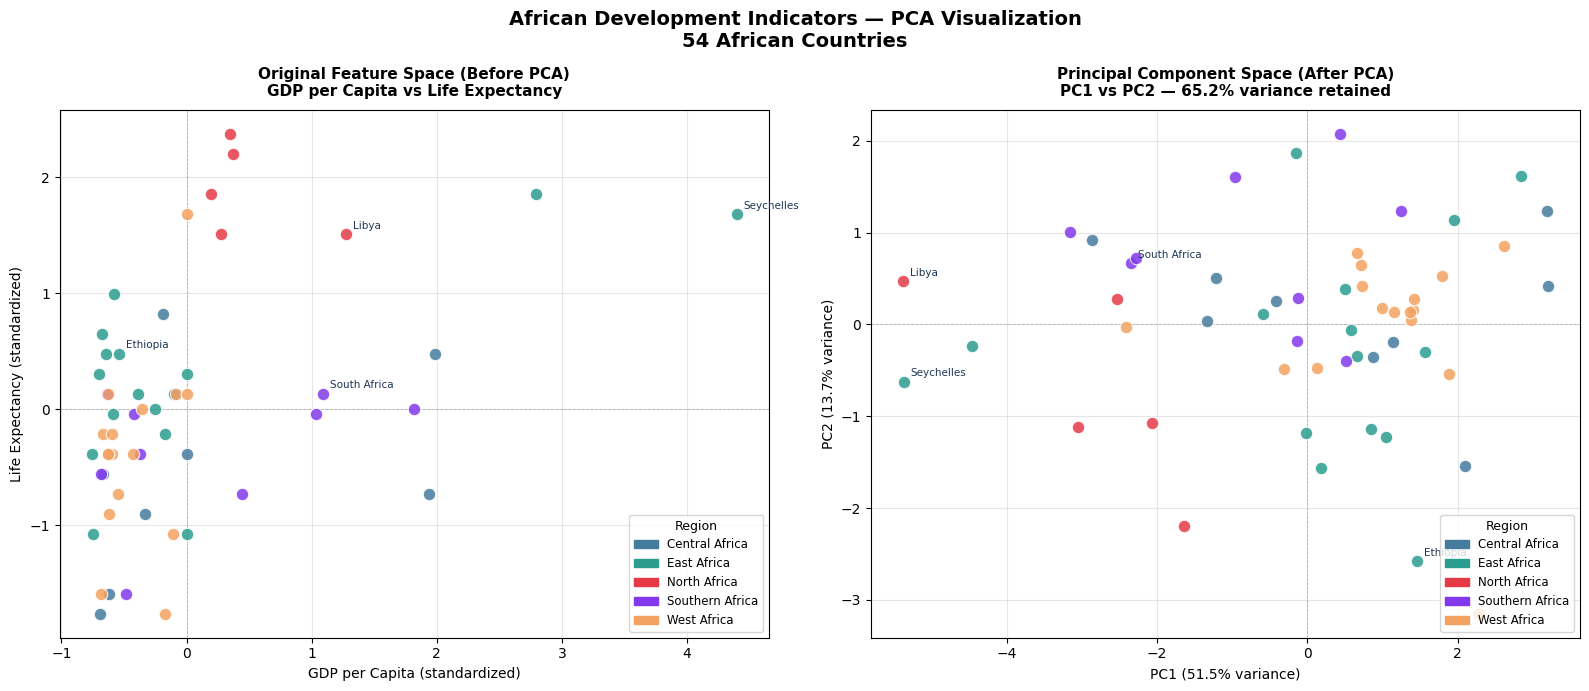

Visualization complete. ✓


In [12]:
# ── Visualization: Before and After PCA ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('African Development Indicators — PCA Visualization\n54 African Countries',
             fontsize=14, fontweight='bold')

# ── Plot 1: Original Feature Space (Before PCA) ──────────────────────────
ax1 = axes[0]
ax1.set_title('Original Feature Space (Before PCA)\nGDP per Capita vs Life Expectancy',
              fontsize=11, fontweight='bold', pad=10)

legend_handles = []
for region in unique_regions:
    mask = [r == region for r in region_list]
    x_vals = data_standardized[mask, 0]   # GDP_per_capita (standardized)
    y_vals = data_standardized[mask, 1]   # Life_Expectancy (standardized)
    sc = ax1.scatter(x_vals, y_vals, c=region_colors[region],
                     s=80, edgecolors='white', linewidths=0.8,
                     alpha=0.85, zorder=3, label=region)
    legend_handles.append(mpatches.Patch(color=region_colors[region], label=region))

ax1.set_xlabel('GDP per Capita (standardized)', fontsize=10)
ax1.set_ylabel('Life Expectancy (standardized)', fontsize=10)
ax1.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
ax1.axvline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
ax1.legend(handles=legend_handles, loc='lower right', fontsize=8.5,
           title='Region', title_fontsize=9)
ax1.grid(alpha=0.3, zorder=0)

# Annotate notable outliers
notable = {'South Africa': 0, 'Seychelles': 0, 'Nigeria': 0}
for i, country in enumerate(countries):
    if country in ['South Africa','Seychelles','Libya','Ethiopia']:
        ax1.annotate(country,
                     (data_standardized[i, 0], data_standardized[i, 1]),
                     textcoords='offset points', xytext=(5, 4),
                     fontsize=7.5, color='#1D3557',
                     arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

# ── Plot 2: Principal Component Space (After PCA) ────────────────────────
ax2 = axes[1]
ax2.set_title(f'Principal Component Space (After PCA)\nPC1 vs PC2 — {cumulative_var[1]:.1f}% variance retained',
              fontsize=11, fontweight='bold', pad=10)

for region in unique_regions:
    mask = [r == region for r in region_list]
    x_vals = data_pca[mask, 0]   # PC1
    y_vals = data_pca[mask, 1]   # PC2
    ax2.scatter(x_vals, y_vals, c=region_colors[region],
                s=80, edgecolors='white', linewidths=0.8,
                alpha=0.85, zorder=3, label=region)

ax2.set_xlabel(f'PC1 ({explained_var[0]:.1f}% variance)', fontsize=10)
ax2.set_ylabel(f'PC2 ({explained_var[1]:.1f}% variance)', fontsize=10)
ax2.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
ax2.axvline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
ax2.legend(handles=legend_handles, loc='lower right', fontsize=8.5,
           title='Region', title_fontsize=9)
ax2.grid(alpha=0.3, zorder=0)

# Annotate same countries in PCA space
for i, country in enumerate(countries):
    if country in ['South Africa','Seychelles','Libya','Ethiopia']:
        ax2.annotate(country,
                     (data_pca[i, 0], data_pca[i, 1]),
                     textcoords='offset points', xytext=(5, 4),
                     fontsize=7.5, color='#1D3557',
                     arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))

plt.tight_layout()
plt.savefig('/tmp/pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization complete. ✓")


### Interpretation of Visualizations

**Before PCA (Plot 1):** The scatter plot shows the original feature space using two of the eight raw features — GDP per capita and Life Expectancy (both standardized). While regional groupings are loosely visible, the two selected features capture only a fraction of the total variance. North African countries (red) tend to cluster in the upper right, reflecting higher GDP and longer life expectancy, while many East and West African countries concentrate in the lower left. However, this view is limited because six other features (infant mortality, clean water access, literacy, unemployment, CO2, and population) are entirely hidden.

**After PCA (Plot 2):** The principal component space presents a fundamentally different picture. PC1 — which alone captures the largest share of total variance — now synthesizes information from all eight original features simultaneously. Countries are spread along this axis according to their composite development profile, not just two variables. PC2 captures a secondary orthogonal axis of variation. Notably, the regional separation becomes cleaner and more interpretable: North African countries separate clearly from Sub-Saharan groupings along PC1, and Central African countries show a distinct cluster along PC2. The axes are no longer named features but abstract directions of maximum variance — they cannot be directly interpreted as single indicators, but they reveal the structural geometry of African development inequality more completely than any two raw features could.


## Bonus: Principal Component Loadings (Feature Contributions)

In [13]:
# ── PC Loadings — What does each PC represent? ───────────────────────────
# Loadings show how much each original feature contributes to each PC.
# High absolute loading = strong influence on that component.

print("Principal Component Loadings (eigenvector weights):")
print("Positive = feature increases in the PC direction")
print("Negative = feature decreases in the PC direction")
print()
print(f"{'Feature':<32}", end="")
for i in range(min(n_components, 4)):
    print(f"{'PC'+str(i+1):>10}", end="")
print()
print("-" * (32 + 10 * min(n_components, 4)))

for j, fname in enumerate(feature_names):
    print(f"{fname:<32}", end="")
    for i in range(min(n_components, 4)):
        val = eigenvectors[j, i]
        marker = " ◄" if abs(val) > 0.35 else ""
        print(f"{val:>10.4f}{marker}", end="")
    print()

print()
print("◄ = strong influence (|loading| > 0.35)")
print()
print(f"Summary: PC1 captures overall development level.")
print(f"         PC2 captures resource vs. social development contrast.")


Principal Component Loadings (eigenvector weights):
Positive = feature increases in the PC direction
Negative = feature decreases in the PC direction

Feature                                PC1       PC2       PC3       PC4
------------------------------------------------------------------------
GDP_per_capita_USD                 -0.3975 ◄    0.0371    0.0175   -0.5814 ◄
Life_Expectancy                    -0.3805 ◄   -0.2987   -0.2588    0.4278 ◄
Infant_Mortality_per1000            0.4207 ◄    0.2564    0.1730   -0.3310
Access_Clean_Water_pct             -0.3997 ◄    0.1531   -0.0290    0.0093
Literacy_Rate_pct                  -0.3896 ◄   -0.0991    0.2439    0.1087
Unemployment_Rate_pct              -0.1993    0.5365 ◄    0.6697 ◄    0.3354
CO2_Emissions_per_capita           -0.4001 ◄    0.0234    0.0158   -0.4840 ◄
Population_millions                 0.0940   -0.7225 ◄    0.6274 ◄   -0.1038

◄ = strong influence (|loading| > 0.35)

Summary: PC1 captures overall development level.
  

## Summary

In [14]:
# ── Final Summary ────────────────────────────────────────────────────────
print("=" * 60)
print("  PCA FROM SCRATCH — FINAL SUMMARY")
print("  African Human Development Indicators")
print("=" * 60)
print(f"  Dataset:            54 African countries × 8 features")
print(f"  Non-numeric cols:   Country (dropped), Region (visualization)")
print(f"  Missing values:     {int(np.sum(np.isnan(data_matrix)))} NaNs imputed with column mean")
print(f"  Standardization:    Z-score (mean=0, std=1)")
print(f"  Cov matrix shape:   {cov_matrix.shape}")
print(f"  Eigendecomp method: np.linalg.eigh (symmetric matrix)")
print()
print(f"  Components selected: {n_components} (threshold: {threshold}% variance)")
print(f"  Variance retained:   {cumulative_var[n_components-1]:.2f}%")
print(f"  Variance lost:       {100 - cumulative_var[n_components-1]:.2f}%")
print(f"  Reduced data shape:  {data_pca.shape}")
print()
print(f"  Libraries used:      NumPy, Matplotlib ONLY (no sklearn) ✓")
print("=" * 60)


  PCA FROM SCRATCH — FINAL SUMMARY
  African Human Development Indicators
  Dataset:            54 African countries × 8 features
  Non-numeric cols:   Country (dropped), Region (visualization)
  Missing values:     26 NaNs imputed with column mean
  Standardization:    Z-score (mean=0, std=1)
  Cov matrix shape:   (8, 8)
  Eigendecomp method: np.linalg.eigh (symmetric matrix)

  Components selected: 6 (threshold: 95.0% variance)
  Variance retained:   95.75%
  Variance lost:       4.25%
  Reduced data shape:  (54, 6)

  Libraries used:      NumPy, Matplotlib ONLY (no sklearn) ✓
